Датасет містить інформацію про рекламні кампанії, включаючи деталі їх розміщення, витрати та взаємодію користувачів. Він охоплює дані про креативи, платформи, рекламодавців і характеристики аудиторії.

План дій:
1. Огляд даних
2. Аналіз бізнес метрик
3. Висновки

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

In [2]:
!ls

marketing_campaign_dataset.ipynb


In [4]:
df = pd.read_csv('Marketing campaign dataset.csv')

# 1. Огляд даних

In [5]:
df.head().T

,0,1,2,3,4
campaign_item_id,2733,2733,2733,2733,2733
no_of_days,7,8,9,10,11
time,2022-05-01,2022-05-02,2022-05-03,2022-05-04,2022-05-05
ext_service_id,128,16,128,128,4
ext_service_name,Facebook Ads,DV360,Facebook Ads,Facebook Ads,Google Ads
creative_id,1000,1000,1000,1000,1000
creative_width,300.0,300.0,300.0,300.0,300.0
creative_height,250.0,250.0,250.0,250.0,250.0
search_tags,#The Power of X,#Be Bold. Be X,#Embrace Your Individuality with X,#Be Bold. Be X,#Be Bold. Be X
template_id,90.0,90.0,90.0,90.0,90.0


In [6]:
df.shape

(72612, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72612 entries, 0 to 72611
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_item_id     72612 non-null  int64  
 1   no_of_days           72612 non-null  int64  
 2   time                 72612 non-null  object 
 3   ext_service_id       72612 non-null  int64  
 4   ext_service_name     72612 non-null  object 
 5   creative_id          72612 non-null  int64  
 6   creative_width       69200 non-null  float64
 7   creative_height      69200 non-null  float64
 8   search_tags          72612 non-null  object 
 9   template_id          69200 non-null  float64
 10  landing_page         72612 non-null  object 
 11  advertiser_id        72612 non-null  int64  
 12  advertiser_name      72612 non-null  object 
 13  network_id           72612 non-null  int64  
 14  approved_budget      72206 non-null  float64
 15  advertiser_currency  72612 non-null 

In [8]:
x = df.isna().sum() / df.shape[0]
x.sort_values(ascending=False)

unique_reach           1.000000
position_in_content    1.000000
total_reach            1.000000
max_bid_cpm            0.898006
template_id            0.046989
creative_height        0.046989
creative_width         0.046989
approved_budget        0.005591
time                   0.000000
campaign_item_id       0.000000
no_of_days             0.000000
landing_page           0.000000
search_tags            0.000000
advertiser_name        0.000000
advertiser_id          0.000000
network_id             0.000000
ext_service_name       0.000000
creative_id            0.000000
ext_service_id         0.000000
channel_name           0.000000
channel_id             0.000000
advertiser_currency    0.000000
network_margin         0.000000
stats_currency         0.000000
campaign_budget_usd    0.000000
impressions            0.000000
clicks                 0.000000
media_cost_usd         0.000000
exchange_rate          0.000000
currency_code          0.000000
search_tag_cat         0.000000
cmi_curr

In [9]:
df.nunique()

campaign_item_id         157
no_of_days               119
time                     224
ext_service_id             3
ext_service_name           3
creative_id             2922
creative_width             2
creative_height            2
search_tags                6
template_id                5
landing_page              45
advertiser_id             47
advertiser_name           44
network_id                 6
approved_budget           61
advertiser_currency        5
channel_id                 5
channel_name               5
max_bid_cpm                1
network_margin             1
campaign_budget_usd      696
impressions             6624
clicks                  1284
stats_currency             5
currency_code              5
exchange_rate              1
media_cost_usd         71753
position_in_content        0
unique_reach               0
total_reach                0
search_tag_cat             5
cmi_currency_code          5
timezone                   7
weekday_cat                2
keywords      

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
campaign_item_id,72612.0,3130.143282,142.154918,2733.000000,3148.000000,3173.000000,3202.000000,3.960000e+03
no_of_days,72612.0,27.036344,25.479175,0.000000,9.000000,19.000000,37.000000,1.180000e+02
ext_service_id,72612.0,49.449127,55.881324,4.000000,4.000000,16.000000,128.000000,1.280000e+02
creative_id,72612.0,7450.124842,4062.384982,1000.000000,3725.000000,7855.000000,10995.000000,1.560500e+04
creative_width,69200.0,267.810694,92.848075,0.000000,300.000000,300.000000,300.000000,3.000000e+02
creative_height,69200.0,223.175578,77.373396,0.000000,250.000000,250.000000,250.000000,2.500000e+02
template_id,69200.0,83.082659,20.847618,23.000000,90.000000,90.000000,90.000000,9.300000e+01
advertiser_id,72612.0,6195.862213,387.864576,4756.000000,6319.000000,6385.000000,6394.000000,6.490000e+03
network_id,72612.0,345.272861,23.707191,188.000000,353.000000,353.000000,353.000000,3.530000e+02
approved_budget,72206.0,125806.417936,562620.400934,400.000000,6000.000000,10000.000000,15000.000000,6.000000e+06


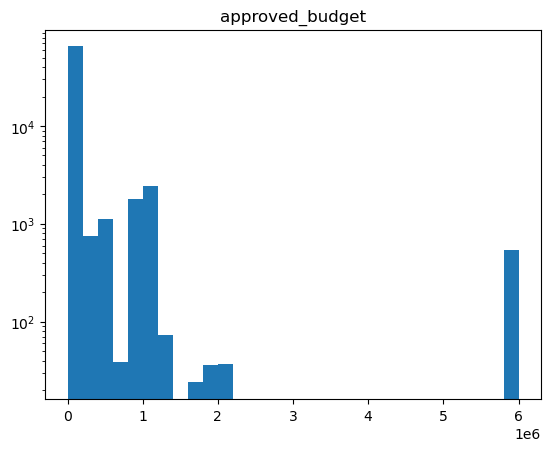

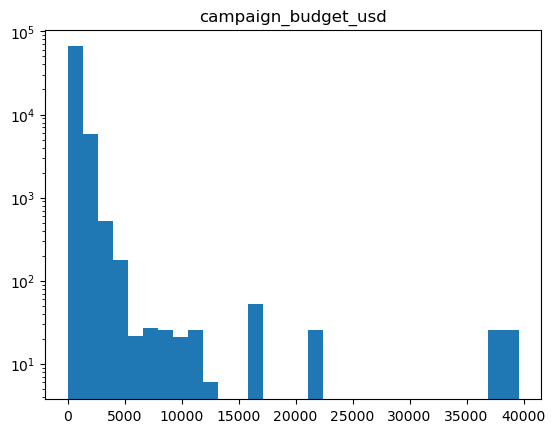

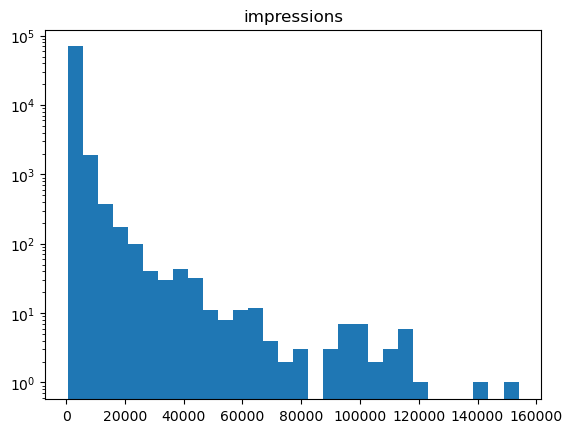

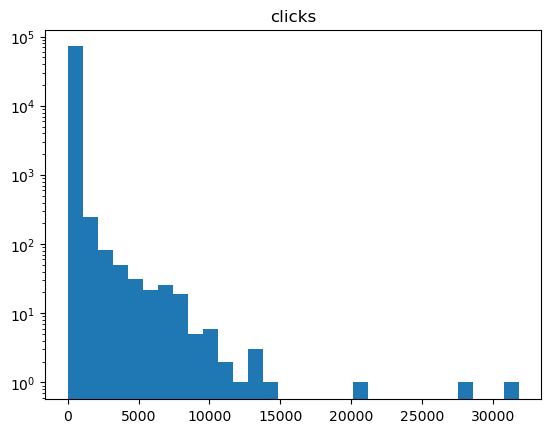

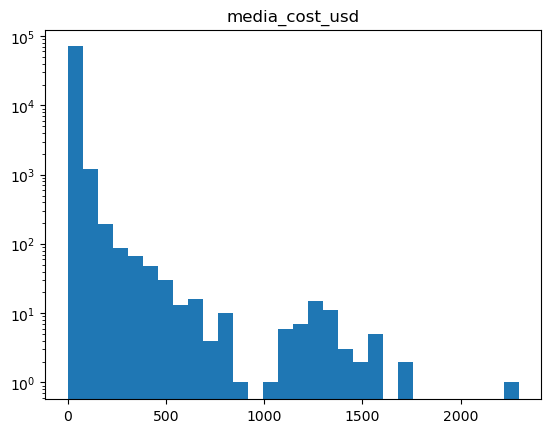

In [12]:
for i in ['approved_budget', 'campaign_budget_usd', 'impressions', 'clicks', 'media_cost_usd']:
    plt.hist(df[i], bins=30)
    plt.title(i)
    plt.yscale('log')
    plt.show();

In [13]:
df.describe(include='object').T

,count,unique,top,freq
time,72612,224,2022-10-22,955
ext_service_name,72612,3,Facebook Ads,24275
search_tags,72612,6,#The Ultimate Fashion Statement with X,12293
landing_page,72612,45,https://www.abcjewelry.com/collections/boho-je...,1684
advertiser_name,72612,44,Oman,8641
advertiser_currency,72612,5,AED,53661
channel_name,72612,5,Mobile,14625
stats_currency,72612,5,AED,53661
currency_code,72612,5,AED,53661
search_tag_cat,72612,5,Others,49008


# 2. Аналіз бізнес метрик

In [162]:
def metrics(df, column):
    df_metrics = df.groupby(column)[['clicks', 'impressions', 'media_cost_usd']] \
                    .agg({'clicks': 'sum', 'impressions': 'sum', 'media_cost_usd': ['sum', 'count']})
    df_metrics.columns = ['_'.join(i) if 'count' not in i else 'count' for i in df_metrics.columns]
    df_metrics.index = df_metrics.index.map(lambda x: str(x)[:20])
    df_metrics['ctr'] = df_metrics['clicks_sum'] / df_metrics['impressions_sum'] * 100
    df_metrics['cpm'] = df_metrics['media_cost_usd_sum'] / df_metrics['impressions_sum'] * 1000
    df_metrics['cpc'] = df_metrics['media_cost_usd_sum'] / df_metrics['clicks_sum']
    return df_metrics.sort_values(by='count', ascending=False)


def metrics_plot(data, column):
    fig, axs = plt.subplots(1, 3, figsize=(20,6))
    
    axs[0].plot(data['ctr'])
    axs[1].plot(data['cpm'])
    axs[2].plot(data['cpc'])
    
    for index, i in enumerate(['ctr', 'cpm', 'cpc']):
        axs[index].plot(x[i])
        title = f'{i} (чим більше, тим краще)' if i == 'ctr' else f'{i} (чим менше, тим краще)'
        axs[index].set_title(title)
        axs[index].tick_params(axis='x', labelrotation=45)
    
    fig.suptitle(column, fontsize=16)
    plt.show();

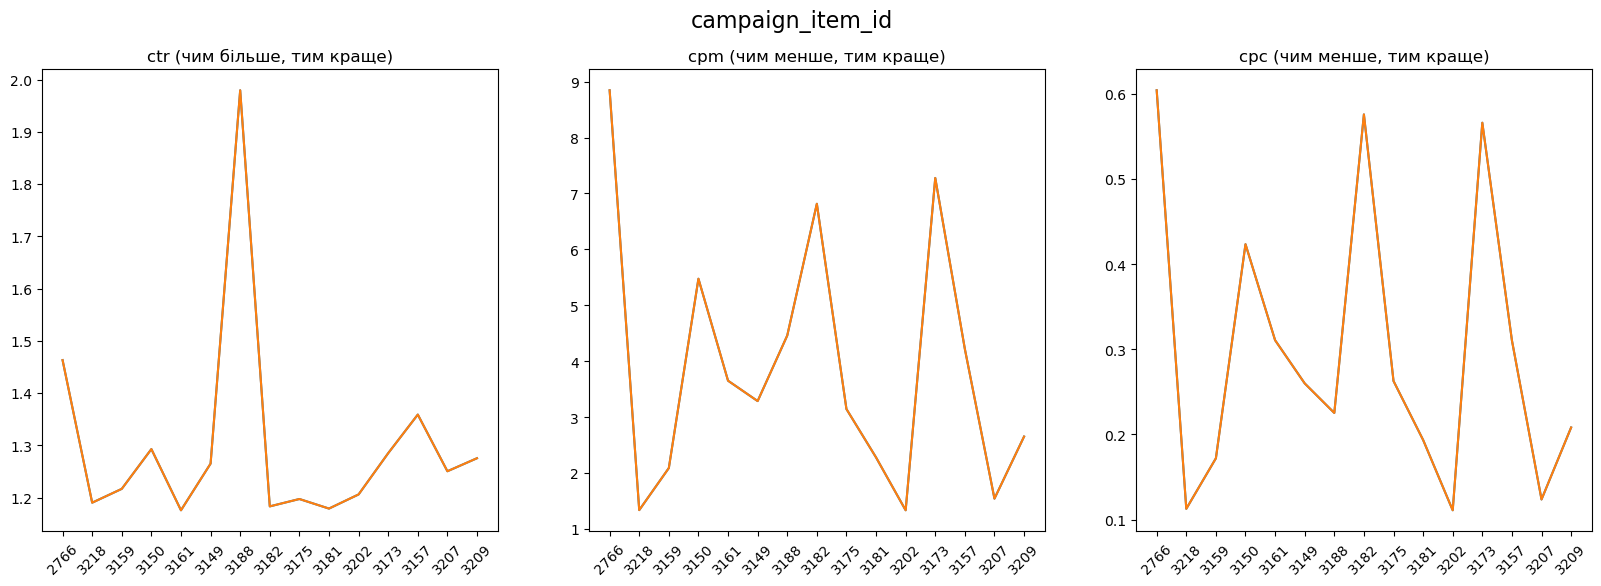

                  count       ctr       cpm       cpc
campaign_item_id                                     
2766               7183  1.463093  8.844160  0.604484
3218               2974  1.190104  1.341190  0.112695
3159               2620  1.216585  2.092885  0.172030
3150               2516  1.292697  5.476173  0.423624
3161               2388  1.175574  3.653688  0.310800
3149               2334  1.264891  3.289572  0.260068
3188               2302  1.979660  4.460876  0.225335
3182               2271  1.183027  6.815610  0.576116
3175               2222  1.197145  3.146967  0.262873
3181               2028  1.178828  2.282439  0.193619
3202               2013  1.205903  1.338045  0.110958
3173               1638  1.284885  7.276882  0.566345
3157               1562  1.358775  4.220399  0.310603
3207               1499  1.250309  1.546239  0.123669
3209               1409  1.275221  2.655631  0.208249 



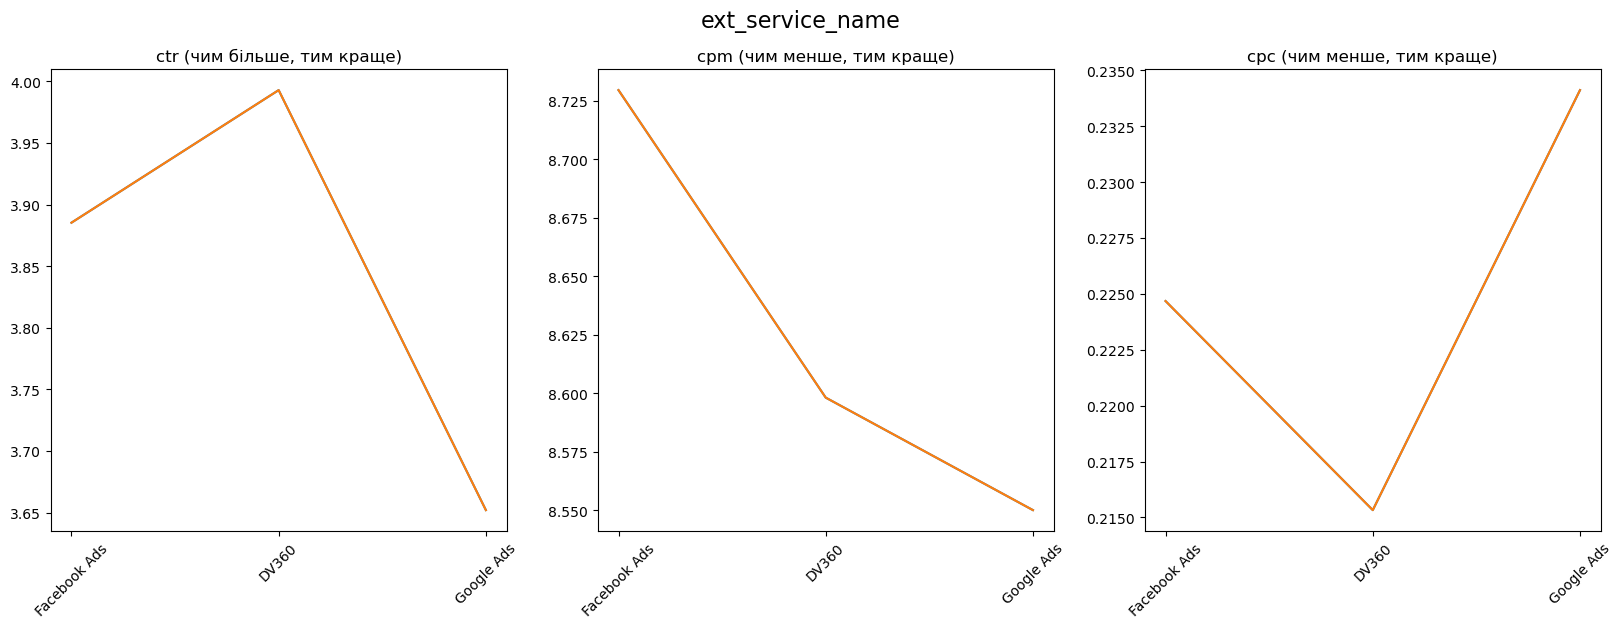

                  count       ctr       cpm       cpc
ext_service_name                                     
Facebook Ads      24275  3.885371  8.729675  0.224681
DV360             24171  3.993000  8.598131  0.215330
Google Ads        24166  3.652056  8.550004  0.234115 



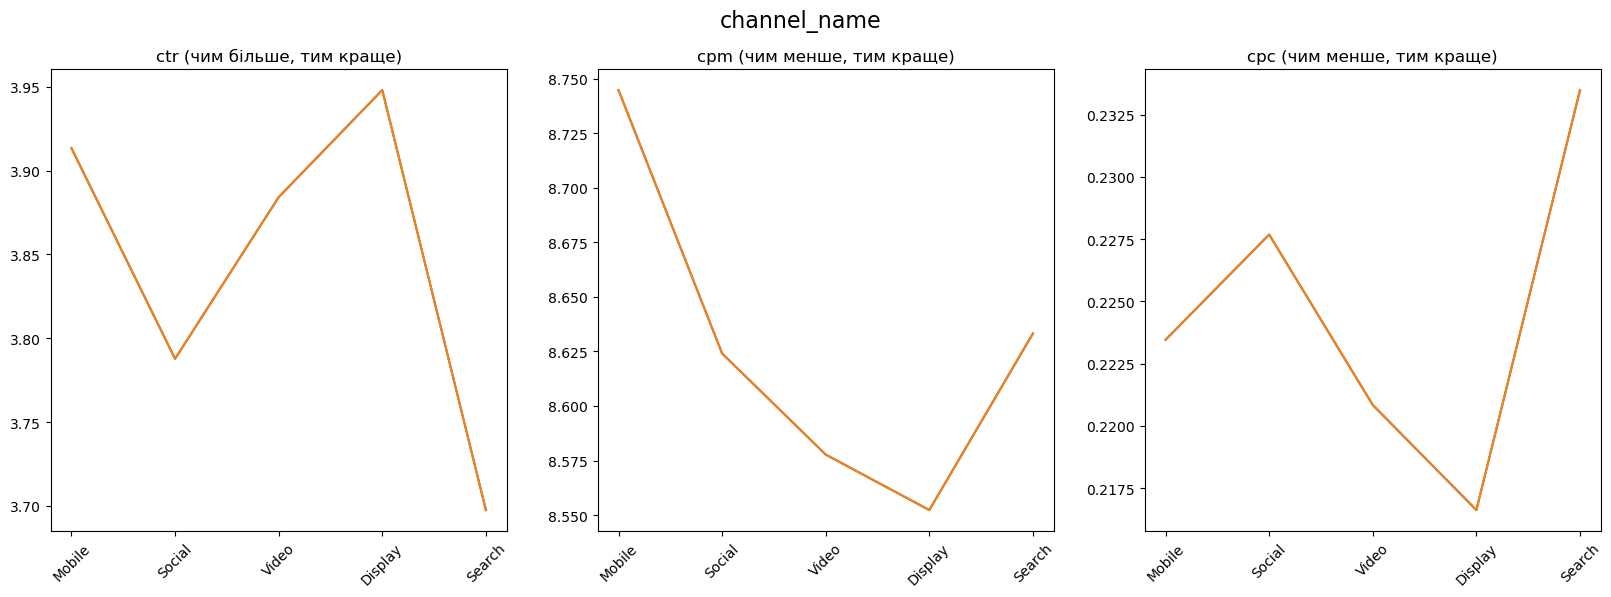

              count       ctr       cpm       cpc
channel_name                                     
Mobile        14625  3.913384  8.744789  0.223458
Social        14576  3.787770  8.624084  0.227682
Video         14525  3.884136  8.577745  0.220840
Display       14447  3.948004  8.552332  0.216624
Search        14439  3.697596  8.633248  0.233483 



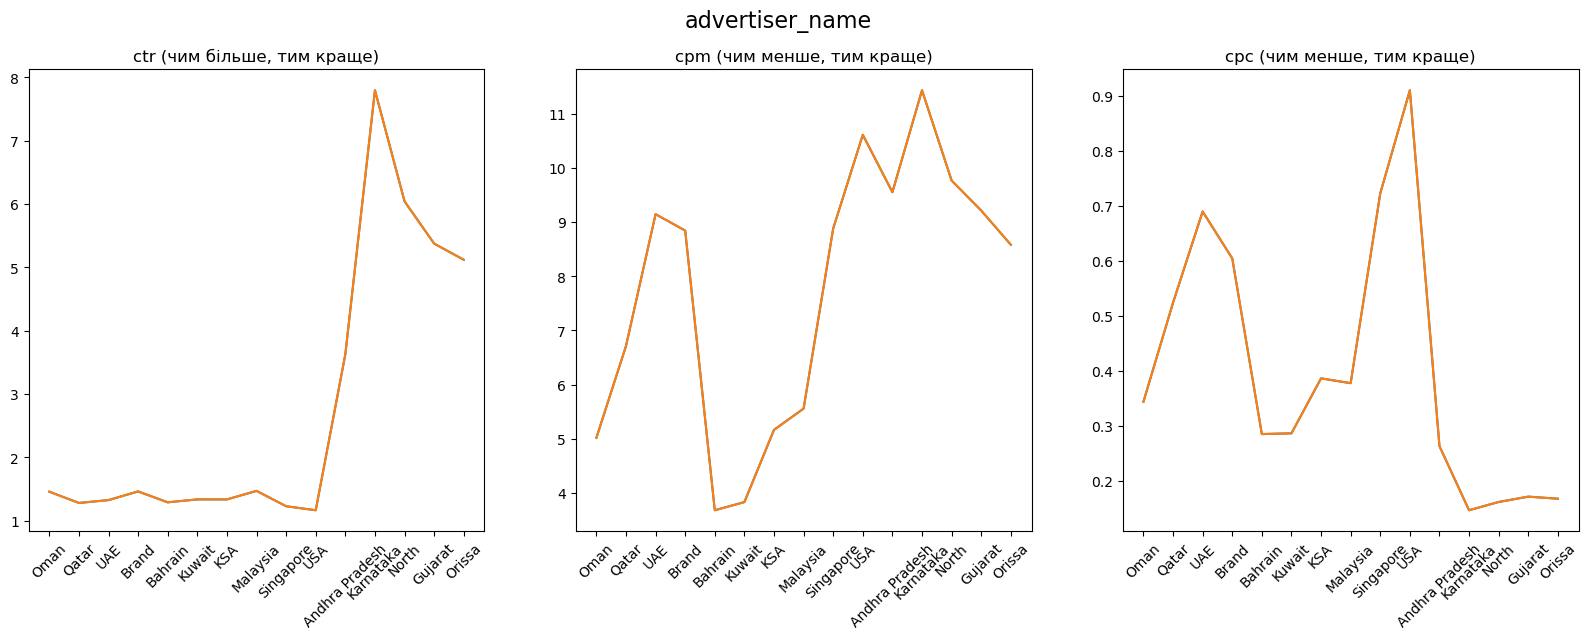

                 count       ctr        cpm       cpc
advertiser_name                                      
Oman              8641  1.458732   5.016712  0.343909
Qatar             7350  1.280875   6.712036  0.524020
UAE               7191  1.326097   9.147110  0.689777
Brand             7183  1.463093   8.844160  0.604484
Bahrain           6469  1.290896   3.680396  0.285104
Kuwait            5973  1.337423   3.831046  0.286450
KSA               5360  1.336616   5.164645  0.386397
Malaysia          4493  1.471547   5.557374  0.377655
Singapore         4165  1.229059   8.882924  0.722742
USA               3926  1.165935  10.612657  0.910227
Andhra Pradesh    1097  3.630413   9.553391  0.263149
Karnataka         1071  7.798455  11.435495  0.146638
North             1046  6.043178   9.768479  0.161645
Gujarat           1022  5.376506   9.213896  0.171373
Orissa            1015  5.121584   8.583277  0.167590 



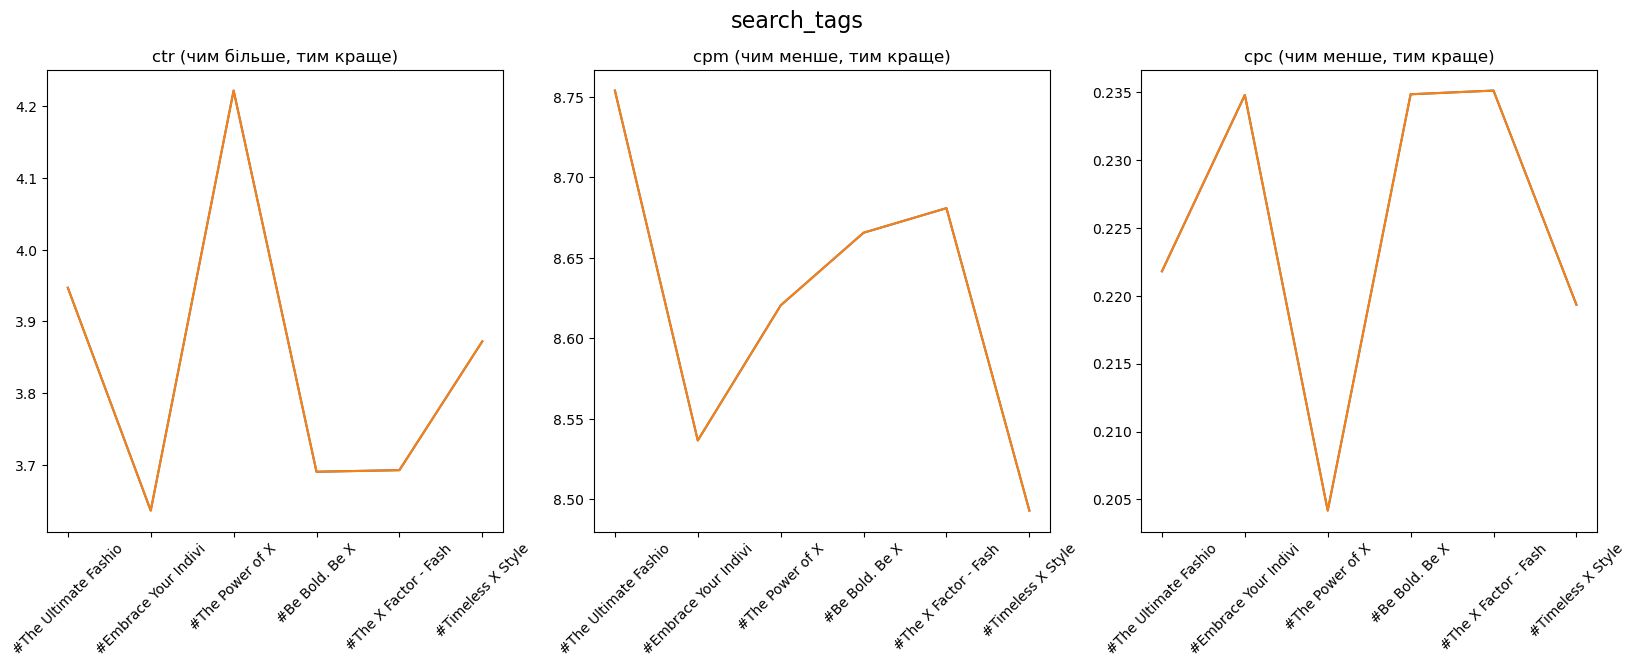

                      count       ctr       cpm       cpc
search_tags                                              
#The Ultimate Fashio  12293  3.946900  8.753825  0.221790
#Embrace Your Indivi  12279  3.636252  8.536564  0.234763
#The Power of X       12116  4.221897  8.620443  0.204184
#Be Bold. Be X        12077  3.690388  8.665554  0.234814
#The X Factor - Fash  11946  3.692607  8.680814  0.235086
#Timeless X Style     11901  3.872198  8.493027  0.219334 



In [163]:
limit = 15 
columns = ['campaign_item_id', 'ext_service_name', 'channel_name', 
           'advertiser_name', 'search_tags']
for i in columns:
    x = metrics(df, i).iloc[:limit]
    metrics_plot(x, i)
    
    print(x[['count', 'ctr', 'cpm', 'cpc']].head(limit), '\n')

In [177]:
keywords = df['keywords'].unique()
keywords = ' '.join(keywords).split()
bag_of_words = Counter(keywords)

bag_of_words

Counter({'jewelry': 83,
         'earrings': 9,
         'bracelets': 6,
         'necklaces': 6,
         'statement': 5,
         'affordable': 5,
         'layered': 4,
         'and': 4,
         'trendy': 4,
         'rings': 4,
         'chic': 3,
         'body': 3,
         'beaded': 2,
         'unique': 2,
         'elegant': 2,
         'modern': 2,
         'costume': 2,
         'sets': 2,
         'fashion': 2,
         'brooches': 2,
         'art': 2,
         'cuffs': 2,
         'luxury': 2,
         'casual': 2,
         'delicate': 1,
         'summer': 1,
         'artisan': 1,
         'minimalist': 1,
         'bridal': 1,
         'clip-on': 1,
         'bohemian': 1,
         'tribal': 1,
         'rhinestone': 1,
         'mixed': 1,
         'metal': 1,
         'colorful': 1,
         'funky': 1,
         'cuff': 1,
         'fashionable': 1,
         'bold': 1,
         'seashell': 1,
         'party': 1,
         'winter': 1,
         'seasonal': 1,
      

In [184]:
def get_popular_keyword(keywords):
    keywords = keywords.split() 
    x = []
    for i in keywords:
        if i in bag_of_words:
            x.append(bag_of_words[i])
    return keywords[np.argmax(x)]

In [185]:
df['popular_keywords'] = df['keywords'].map(get_popular_keyword)

In [190]:
df['popular_keywords'].value_counts(normalize=True)

popular_keywords
jewelry      0.703258
earrings     0.077343
necklaces    0.050350
bracelets    0.049179
rings        0.025588
cuffs        0.017118
statement    0.016747
body         0.016499
bangles      0.009172
hair         0.009076
brooches     0.008704
fashion      0.008525
anklets      0.008442
Name: proportion, dtype: float64

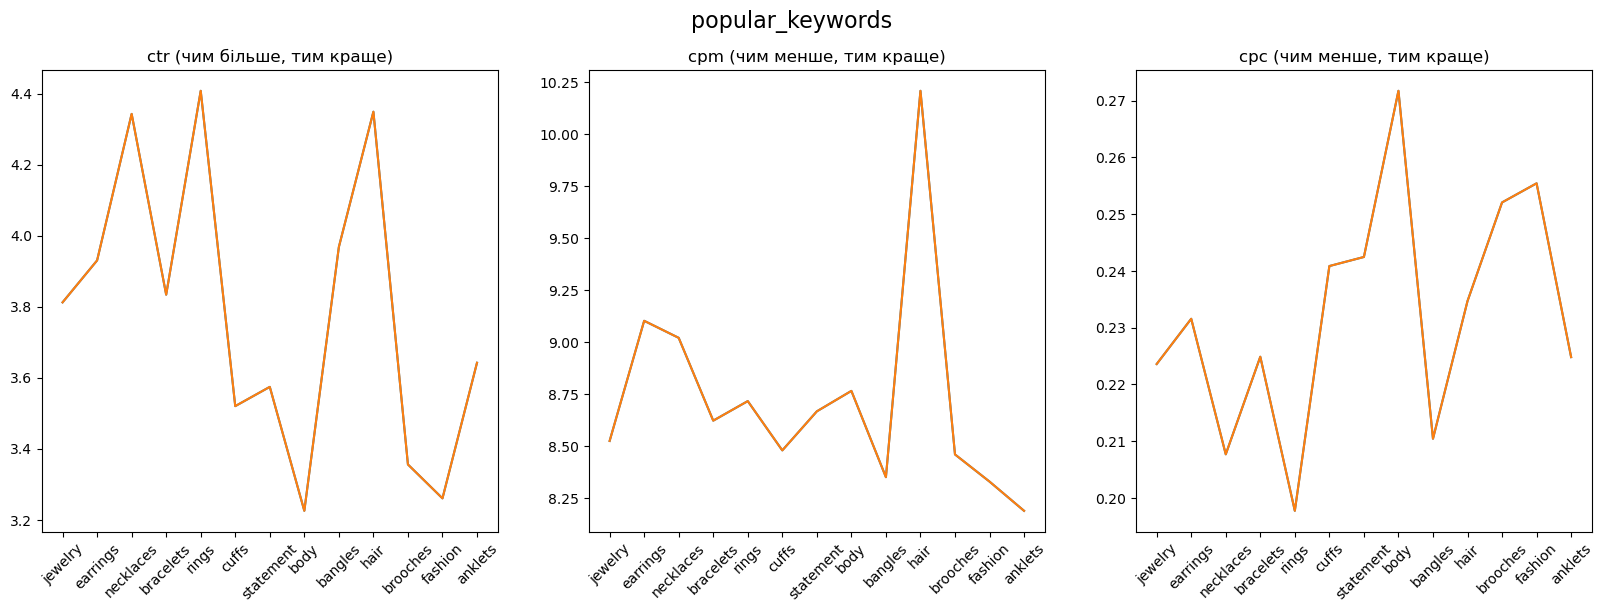

                  count       ctr        cpm       cpc
popular_keywords                                      
jewelry           51065  3.812249   8.524129  0.223598
earrings           5616  3.930374   9.101624  0.231571
necklaces          3656  4.342898   9.019686  0.207688
bracelets          3571  3.833827   8.621672  0.224884
rings              1858  4.407858   8.715681  0.197731
cuffs              1243  3.520122   8.478719  0.240864
statement          1216  3.574324   8.666441  0.242464
body               1198  3.225346   8.764747  0.271746
bangles             666  3.968049   8.350035  0.210432
hair                659  4.349057  10.207077  0.234696
brooches            632  3.355853   8.459280  0.252075
fashion             619  3.260489   8.328755  0.255445
anklets             613  3.642214   8.188299  0.224817 



In [189]:
x = metrics(df, 'popular_keywords').iloc[:limit]
metrics_plot(x, 'popular_keywords')

print(x[['count', 'ctr', 'cpm', 'cpc']].head(limit), '\n')

# 3. Висновки

Усі маркетингові кампанії демонструють приблизно однаковий рівень CTR, за винятком кампанії 3188, де цей показник майже вдвічі вищий (2%).

Найнижча вартість за 1000 показів зафіксована у кампаній 3218 (1.34 usd), 3202 (1.34 usd) і 3207 (1.55 usd), тоді як найвищі значення спостерігаються у 2766 (8.84 usd), 3182 (6.81 usd) і 3173 (7.27 usd).

Вартість кліка найнижча у 3218 (0.11 usd), 3202 (0.11 usd) і 3207 (0.12 usd), тоді як найдорожчі кліки у 2766 (0.6 usd), 3182 (0.57 usd) і 3173 (0.56 usd).

Рекламна платформа DV360 показує найвищий CTR (4%) і найнижчу вартість кліка (0.21 usd) у порівнянні з Facebook Ads і Google Ads. Проте вартість за 1000 показів тут трохи вища, ніж у Google Ads (8.6 usd проти 8.55 usd).

Канал "Display" є безперечним лідером за метриками: CTR 3.95%, CPM 8.55 usd, CPC 0.21 usd.

Регіон Karnataka (Індія) демонструє високий CTR (7.8%) і низьку вартість кліка (0.14 usd), але водночас найдорожчу вартість за 1000 показів (11.4 usd). Якщо користувачі з цього регіону мають високу цінність для сервісу, варто продовжувати маркетингові вкладення, незважаючи на високу ціну за охоплення.

Найефективніші ключові слова: "rings" (CTR 4.4%, CPM 8.71 usd, CPC 0.2 usd) та "necklaces" (CTR 4.34%, CPM 9.01 usd, CPC 0.2 usd). Водночас ключове слово "jewelry", що використовується у 70% випадків, має менш привабливі метрики: CTR 3.81%, CPM 8.52 usd, CPC 0.22 usd.


Аналіз показує, що кампанія 3188 має найвищий CTR, що може свідчити про її високу релевантність або ефективні креативи. Найменша вартість за 1000 показів та кліки спостерігається у кампаній 3218, 3202 і 3207, що робить їх найбільш економічно вигідними з точки зору охоплення та залучення трафіку. Крім того, платформа DV360 демонструє найкраще співвідношення між CTR і вартістю кліка, а регіон Karnataka виділяється високою залученістю аудиторії, хоча й має високу ціну за охоплення. Канал "Display" є безперечним лідером за метриками. Ключові слова "rings" та "necklaces" маю кращі показники за "jewelry". Це означає, що більш вузькі та спеціалізовані ключові слова приносять кращі результати.